# Phase 5 V2 — Prescience Scoring & Feature Engineering (USD-Weighted Win Rate)

**CS-GY 6513 Big Data, Spring 2026**  
Rodrigo Arguello (ra2646) | Shwetanshu Raj (sr8250)

---

## Overview

Phase 4 identified **13,068 distinct suspect wallets** — addresses that traded in the correct direction before price spikes. Not all of them had inside information. Many were simply active traders who happened to be in the market around spike windows.

This phase introduces an external ground truth: **GDELT news mentions**. If a wallet placed their bet *before* any news article about that market's topic was crawled by GDELT, they could not have been reacting to public information. That is the prescience signal.

### Pipeline

1. Load `polymarket.suspect_wallets` from BigQuery (Spark)
2. Query **GDELT eventmentions** (`gdelt-bq.gdeltv2.eventmentions` joined with `gdelt-bq.gdeltv2.events`) per market using keyword mappings — returns article-level timestamps with **15-minute precision** via `MentionTimeDate`
3. **Temporal join**: for each suspect wallet entry, find the nearest GDELT mention that appeared *after* their `first_bet_timestamp` on the same market topic — full timestamp comparison, not date-only
4. Compute `time_before_news_hours` and `bet_before_news` flag
5. Aggregate a **feature vector** per wallet:
   - `prescience_score` — fraction of bets placed before any relevant news mention
   - `win_rate` — fraction of bets in resolved markets on the winning side
   - `avg_hours_before_news` — how far in advance of news suspects typically bet
   - `avg_bet_size_usd`, `num_spikes_flagged`, `num_markets_traded`, `taker_fraction`
6. Write `polymarket.wallet_features` to BigQuery

### Why GDELT Eventmentions (not Events)?

GDELT `gdelt-bq.gdeltv2.events` provides `SQLDATE` as a date-only integer (YYYYMMDD). This makes intra-day ordering impossible — a bet at 10am and news at 9am the same day look identical. The **eventmentions table** fixes this: `MentionTimeDate` is stored as YYYYMMDDHHMMSS, giving 15-minute crawl-slot precision. We join events (for actor keyword filtering) with eventmentions (for article timestamps) to get the best of both tables.

---

## 1. Setup

### 1.1 Imports and Constants

In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

# ── GCP config ────────────────────────────────────────────────────────────────
PROJECT = "sr8250-cs6513-polymarket"
DATASET = "polymarket"

# We join the events table (actor keywords + NumArticles filter) with the
# eventmentions table (MentionTimeDate gives YYYYMMDDHHMMSS — 15-minute precision).
# This replaces the events-only approach which only gave date-level precision.
GDELT_EVENTS_TABLE    = "gdelt-bq.gdeltv2.events"
GDELT_MENTIONS_TABLE  = "gdelt-bq.gdeltv2.eventmentions"

ROOT = Path.cwd().parent
JAR = str(ROOT / "jars" / "spark-bigquery-with-dependencies_2.12-0.36.1.jar")

SPARK_MASTER = "local[*]"

# ── Scoring parameters ────────────────────────────────────────────────────────
MIN_GDELT_ARTICLES = 5
MIN_SPIKES_FOR_SCORE = 2

RESOLVED_YES_MARKETS = [
    "us-strikes-iran-feb28",
    "khamenei-out-feb28",
    "maduro-out-jan31",
]

CHART_DIR = Path("score_v2_charts")
CHART_DIR.mkdir(exist_ok=True)

### 1.2 GDELT Keyword Mappings

For each market we define:
- `actor_patterns` — GDELT `Actor1Name` / `Actor2Name` substrings that identify relevant news (verified against live GDELT data)
- `date_start` / `date_end` — the YYYYMMDD window to search (covers market collection period)
- `min_articles` — minimum NumArticles threshold (lower for markets with sparse coverage like Khamenei)

These mappings were confirmed by running the test script in `test_scripts/test_gdelt.py` against live GDELT data.

In [2]:
MARKET_GDELT_CONFIG = {
    "us-strikes-iran-feb28": {
        "actor_patterns": ["IRAN", "IRANIAN", "TEHRAN"],
        "date_start": "20251001",
        "date_end": "20260301",
        "min_articles": MIN_GDELT_ARTICLES,
        "note": "US military strikes against Iran; resolved Feb 28 2026 (YES)",
    },
    "khamenei-out-feb28": {
        # GDELT uses full 'AYATOLLAH KHAMENEI' — confirmed from test
        "actor_patterns": ["KHAMENEI", "AYATOLLAH KHAMENEI"],
        "date_start": "20251001",
        "date_end": "20260301",
        "min_articles": 3,   # Khamenei events have fewer articles; lower threshold
        "note": "Khamenei removal from power in Iran; resolved Feb 28 2026 (YES)",
    },
    "maduro-out-jan31": {
        "actor_patterns": ["MADURO", "VENEZUELA", "VENEZUELAN"],
        "date_start": "20251101",
        "date_end": "20260201",
        "min_articles": MIN_GDELT_ARTICLES,
        "note": "Maduro removal from power; resolved Jan 3 2026 (YES)",
    },
    "us-forces-iran-mar31": {
        # Broader keywords — covers US military posture and engagement with Iran
        "actor_patterns": ["IRAN", "IRANIAN", "TEHRAN"],
        "date_start": "20260101",
        "date_end": "20260401",
        "min_articles": MIN_GDELT_ARTICLES,
        "note": "US forces engagement with Iran; active market",
    },
    "us-iran-ceasefire-jun30": {
        "actor_patterns": ["IRAN", "IRANIAN"],
        "date_start": "20260101",
        "date_end": "20260701",
        "min_articles": MIN_GDELT_ARTICLES,
        "note": "US-Iran ceasefire agreement; active market",
    },
    "china-invades-taiwan-2026": {
        # Confirmed Taiwan events exist: Actor1Name 'TAIWAN', 'TAIWANESE'
        "actor_patterns": ["TAIWAN", "TAIWANESE"],
        "date_start": "20250701",
        "date_end": "20261231",
        "min_articles": MIN_GDELT_ARTICLES,
        "note": "China military invasion of Taiwan; long-horizon active market",
    },
}

print(f"Markets configured: {len(MARKET_GDELT_CONFIG)}")
for slug, cfg in MARKET_GDELT_CONFIG.items():
    print(f"  {slug}: actors={cfg['actor_patterns']}, window={cfg['date_start']}–{cfg['date_end']}")

Markets configured: 6
  us-strikes-iran-feb28: actors=['IRAN', 'IRANIAN', 'TEHRAN'], window=20251001–20260301
  khamenei-out-feb28: actors=['KHAMENEI', 'AYATOLLAH KHAMENEI'], window=20251001–20260301
  maduro-out-jan31: actors=['MADURO', 'VENEZUELA', 'VENEZUELAN'], window=20251101–20260201
  us-forces-iran-mar31: actors=['IRAN', 'IRANIAN', 'TEHRAN'], window=20260101–20260401
  us-iran-ceasefire-jun30: actors=['IRAN', 'IRANIAN'], window=20260101–20260701
  china-invades-taiwan-2026: actors=['TAIWAN', 'TAIWANESE'], window=20250701–20261231


### 1.3 Spark Session and BigQuery Client

In [3]:
spark = (
    SparkSession.builder
    .appName("polymarket-prescience-scoring")
    .master(SPARK_MASTER)
    .config("spark.jars", JAR)
    .config("spark.driver.host", "localhost")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# BigQuery Python client — used for GDELT queries (external project)
bq_client = bigquery.Client(project=PROJECT)

print(f"Spark version : {spark.version}")
print(f"Master        : {spark.sparkContext.master}")
print(f"BQ project    : {PROJECT}")

26/05/03 10:05:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version : 3.5.1
Master        : local[*]
BQ project    : sr8250-cs6513-polymarket


### 1.4 Helper: Write DataFrame to BigQuery

In [4]:
def write_bq(df, table):
    """
    Writes a Spark DataFrame to a BigQuery table, overwriting any existing data

    Args:
        df: The Spark DataFrame to write
        table: The BigQuery table name within the configured dataset
    """
    (
        df.repartition(2)
        .write
        .format("bigquery")
        .option("table", f"{PROJECT}.{DATASET}.{table}")
        .option("writeMethod", "direct")
        .mode("overwrite")
        .save()
    )

---

## 2. Load Suspect Wallets from BigQuery

In [5]:
t0 = time.time()

suspects = (
    spark.read
    .format("bigquery")
    .option("table", f"{PROJECT}.{DATASET}.suspect_wallets")
    .load()
)

suspect_count = suspects.count()
elapsed = time.time() - t0

print(f"Suspect wallet entries : {suspect_count:,}")
print(f"Time                  : {elapsed:.1f}s")
suspects.printSchema()

Suspect wallet entries : 128,096
Time                  : 3.3s
root
 |-- spike_id: long (nullable = false)
 |-- market_slug: string (nullable = true)
 |-- spike_side: string (nullable = true)
 |-- spike_timestamp: timestamp (nullable = true)
 |-- wallet_address: string (nullable = true)
 |-- role: string (nullable = false)
 |-- total_usd: double (nullable = true)
 |-- fill_count: long (nullable = false)
 |-- avg_price: double (nullable = true)
 |-- first_bet_timestamp: timestamp (nullable = true)
 |-- hours_before_spike: double (nullable = true)



> **What this output means:**
>
> We loaded the 128,096 (wallet, spike) pairs from Phase 4. Each row is one wallet's activity around one spike event. The schema shows:
> - `wallet_address` / `role` — who the wallet is (taker = bought correct side, maker = sold opposite side)
> - `market_slug` / `spike_side` / `spike_timestamp` — which spike this entry corresponds to
> - `total_usd` / `fill_count` / `avg_price` — position size and entry price in the look-back window
> - `first_bet_timestamp` — when this wallet first traded in the 24-hour look-back window
> - `hours_before_spike` — how many hours before the spike their first bet was
>
> This table drives the rest of Phase 5. For each row we will ask: was `first_bet_timestamp` before any relevant news appeared about this market?

---

## 3. Query GDELT News Mentions

We use the **BigQuery Python client** to query GDELT via a join of two tables:

- `gdelt-bq.gdeltv2.events` — filtered by actor keywords + NumArticles threshold to identify relevant events  
- `gdelt-bq.gdeltv2.eventmentions` — each row is one article mention of an event; `MentionTimeDate` is stored as a `YYYYMMDDHHMMSS` integer with **15-minute precision** (when GDELT's crawler first saw the article)

**Why eventmentions instead of events?**  
The events table `SQLDATE` field is a date-only integer (YYYYMMDD). A bet placed at 11pm on Feb 27 and news that broke at 2am on Feb 28 land on different calendar dates, but a bet at 10am and news at 9am the same day look identical to the pipeline. The eventmentions table fixes this — `MentionTimeDate = 20260228054500` means the article was crawled at 05:45 UTC on Feb 28, giving us intra-day ordering.

The join: events supply actor name filtering; eventmentions supply the actual article timestamps. We return distinct `mention_timestamp` values per market.

In [6]:
def query_gdelt_market(market_slug, config):
    """
    Queries GDELT eventmentions for article-level timestamps relevant to a single market.
    Joins gdelt-bq.gdeltv2.events (actor keyword filter) with
    gdelt-bq.gdeltv2.eventmentions (MentionTimeDate — 15-min precision timestamp).

    Args:
        market_slug: market identifier added as a column to results
        config: dict with actor_patterns, date_start, date_end, min_articles

    Returns:
        pandas DataFrame with columns: market_slug, mention_timestamp
    """
    patterns = config["actor_patterns"]
    # No table alias inside a CTE body — reference columns directly
    actor_clauses = " OR ".join(
        f"(Actor1Name LIKE '%{p}%' OR Actor2Name LIKE '%{p}%')" for p in patterns
    )
    dt_start = int(config["date_start"]) * 1_000_000
    dt_end   = int(config["date_end"])   * 1_000_000 + 235959

    sql = f"""
        WITH rel_events AS (
            SELECT GLOBALEVENTID
            FROM `{GDELT_EVENTS_TABLE}`
            WHERE SQLDATE BETWEEN {config["date_start"]} AND {config["date_end"]}
              AND ({actor_clauses})
              AND NumArticles >= {config["min_articles"]}
        )
        SELECT DISTINCT
            PARSE_TIMESTAMP(
                '%Y%m%d%H%M%S',
                LPAD(CAST(m.MentionTimeDate AS STRING), 14, '0')
            ) AS mention_timestamp
        FROM `{GDELT_MENTIONS_TABLE}` m
        JOIN rel_events e ON m.GLOBALEVENTID = e.GLOBALEVENTID
        WHERE m.MentionTimeDate BETWEEN {dt_start} AND {dt_end}
    """
    df = bq_client.query(sql).to_dataframe()
    df["market_slug"] = market_slug
    df["mention_timestamp"] = (
        pd.to_datetime(df["mention_timestamp"], utc=True)
        .dt.tz_localize(None)
    )
    return df

In [7]:
print("Querying GDELT mentions per market (events × mentions join)...")
all_gdelt = []

for slug, config in MARKET_GDELT_CONFIG.items():
    t0 = time.time()
    df = query_gdelt_market(slug, config)
    all_gdelt.append(df)
    print(f"  {slug}: {len(df):,} distinct mention timestamps ({time.time()-t0:.1f}s)")

gdelt_pd = pd.concat(all_gdelt, ignore_index=True)
print(f"\nTotal distinct mention timestamps across all markets : {len(gdelt_pd):,}")
print(f"Date range covered : {gdelt_pd['mention_timestamp'].min()} → {gdelt_pd['mention_timestamp'].max()}")

Querying GDELT mentions per market (events × mentions join)...


/Users/shwetanshu/Documents/Projects/CS-GY6513-FinalProject/venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  us-strikes-iran-feb28: 13,972 distinct mention timestamps (3.0s)


/Users/shwetanshu/Documents/Projects/CS-GY6513-FinalProject/venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  khamenei-out-feb28: 263 distinct mention timestamps (2.1s)


...

  us-forces-iran-mar31: 8,728 distinct mention timestamps (2.8s)


/Users/shwetanshu/Documents/Projects/CS-GY6513-FinalProject/venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  us-iran-ceasefire-jun30: 11,761 distinct mention timestamps (2.8s)


/Users/shwetanshu/Documents/Projects/CS-GY6513-FinalProject/venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  china-invades-taiwan-2026: 18,816 distinct mention timestamps (2.5s)

Total distinct mention timestamps across all markets : 62,335
Date range covered : 2025-07-02 02:30:00 → 2026-05-03 14:15:00


> **What this output means:**
>
> For each market we pulled GDELT news events matching the configured actor keywords within the market's time window. The event counts vary by market:
> - Markets with broad keywords (IRAN, IRANIAN) covering a major ongoing conflict return more events
> - Khamenei-specific events are sparser (his name appears less frequently as a direct GDELT actor)
> - Taiwan events are available throughout the long-running market window
>
> The total event count tells us how many distinct news moments exist across all markets. Each of these events is a potential "information release" that a wallet could have bet before or after.

### Preview: Most-Covered GDELT Events per Market

In [8]:
# Earliest and latest mention per market — sanity check that timestamps look right
preview = (
    gdelt_pd
    .groupby("market_slug")["mention_timestamp"]
    .agg(earliest="min", latest="max", count="count")
    .reset_index()
    .sort_values("count", ascending=False)
)
print("Mention timestamp coverage per market:")
print(preview.to_string(index=False))

print("\nSample mention timestamps for khamenei-out-feb28 (should show hours, not midnight):")
sample = (
    gdelt_pd[gdelt_pd["market_slug"] == "khamenei-out-feb28"]
    .sort_values("mention_timestamp")
    .head(10)
)
print(sample[["mention_timestamp"]].to_string(index=False))

Mention timestamp coverage per market:
              market_slug            earliest              latest  count
china-invades-taiwan-2026 2025-07-02 02:30:00 2026-05-03 14:15:00  18816
    us-strikes-iran-feb28 2025-10-01 00:00:00 2026-03-01 23:45:00  13972
  us-iran-ceasefire-jun30 2026-01-01 00:00:00 2026-05-03 14:15:00  11761
         maduro-out-jan31 2025-11-01 00:00:00 2026-02-01 23:45:00   8795
     us-forces-iran-mar31 2026-01-01 00:00:00 2026-04-01 23:45:00   8728
       khamenei-out-feb28 2025-10-03 13:45:00 2026-03-01 23:45:00    263

Sample mention timestamps for khamenei-out-feb28 (should show hours, not midnight):
  mention_timestamp
2025-10-03 13:45:00
2025-10-03 16:00:00
2025-10-03 16:45:00
2025-10-08 23:45:00
2025-10-17 14:15:00
2025-10-19 15:30:00
2025-10-20 16:30:00
2025-10-20 18:00:00
2025-10-23 15:30:00
2025-10-24 09:30:00


> **What this output means:**
>
> The first table confirms coverage per market — the timestamp range should span the market's collection window and the count shows how many distinct 15-minute crawl slots contained relevant articles.
>
> The sample timestamps for Khamenei are the key check: with the old events table all entries would show midnight (`00:00:00`) since SQLDATE was date-only. With the mentions table the timestamps should show real hours and minutes (e.g., `2026-01-26 08:15:00`). This means a bet placed at 06:00 UTC on Jan 26 would now correctly be flagged as *before* news that broke at 08:15, whereas before both would have been on the same calendar date with no ordering.

---

## 4. Convert GDELT Mentions to Spark and Prepare Look-up Table

We only need the unique `(market_slug, mention_timestamp)` pairs for the temporal join. Each row is a 15-minute crawl slot where at least one relevant article appeared. The broadcast table is still small (thousands of rows) even with sub-day precision.

In [9]:
gdelt_ts_pd = (
    gdelt_pd[["market_slug", "mention_timestamp"]]
    .drop_duplicates()
    .sort_values(["market_slug", "mention_timestamp"])
    .reset_index(drop=True)
)

gdelt_ts_spark = spark.createDataFrame(gdelt_ts_pd)
gdelt_ts_count = gdelt_ts_spark.count()

print(f"Unique (market, mention_timestamp) pairs : {gdelt_ts_count:,}")
gdelt_ts_spark.groupBy("market_slug").count().orderBy("market_slug").show(truncate=False)

Unique (market, mention_timestamp) pairs : 62,335


+-------------------------+-----+
|market_slug              |count|
+-------------------------+-----+
|china-invades-taiwan-2026|18816|
|khamenei-out-feb28       |263  |
|maduro-out-jan31         |8795 |
|us-forces-iran-mar31     |8728 |
|us-iran-ceasefire-jun30  |11761|
|us-strikes-iran-feb28    |13972|
+-------------------------+-----+



> **What this output means:**
>
> Each row is a distinct 15-minute crawl slot where GDELT found at least one article matching the market's actor keywords. The count per market tells us how many mention slots exist — this is higher than the old event-date count because the same calendar date can have many distinct 15-minute slots.
>
> This lookup table is broadcast to all Spark executors. Each suspect wallet entry is then matched against it: given a `first_bet_timestamp`, we find the smallest `mention_timestamp` that is strictly greater — the first article GDELT crawled after the wallet placed their bet.

---

## 5. Temporal Join — Find Nearest News Mention After Each Bet

For each suspect wallet entry we ask: *what was the first GDELT article mention for this market topic that appeared after this wallet's first bet?*

The join condition:
- Same `market_slug`
- `mention_timestamp > first_bet_timestamp` (news mention crawled **after** the bet — full timestamp comparison, 15-min precision)

We take `MIN(mention_timestamp)` per wallet entry to get the *nearest* subsequent article. A left join retains entries with no subsequent mention (active markets with no coverage yet or bets placed after the last crawl in our window).

In [10]:
t0 = time.time()

suspects_cols = suspects.columns

suspects_news = (
    suspects.alias("sw")
    .join(
        F.broadcast(gdelt_ts_spark).alias("g"),
        (
            (F.col("sw.market_slug") == F.col("g.market_slug")) &
            # Full timestamp comparison — 15-min precision instead of date-only
            (F.col("g.mention_timestamp") > F.col("sw.first_bet_timestamp"))
        ),
        "left",
    )
    .groupBy(*[F.col(f"sw.{c}") for c in suspects_cols])
    .agg(F.min("g.mention_timestamp").alias("nearest_mention_ts"))
    .withColumn(
        "time_before_news_hours",
        F.when(
            F.col("nearest_mention_ts").isNotNull(),
            F.round(
                (F.unix_timestamp("nearest_mention_ts") -
                 F.unix_timestamp("first_bet_timestamp")) / 3600,
                2,
            ),
        )
    )
    .withColumn(
        "bet_before_news",
        F.when(F.col("time_before_news_hours") > 0, True).otherwise(False),
    )
)

joined_count = suspects_news.count()
elapsed = time.time() - t0

print(f"Joined rows             : {joined_count:,}")
print(f"Time                    : {elapsed:.1f}s")

suspects_news.groupBy(
    F.col("nearest_mention_ts").isNotNull().alias("has_mention_after_bet")
).count().show()

Joined rows             : 128,096
Time                    : 3.9s


+---------------------+------+
|has_mention_after_bet| count|
+---------------------+------+
|                 true|128096|
+---------------------+------+



> **What this output means:**
>
> Row count should match 128,096 (left join preserves all suspect entries). The split between `has_mention_after_bet = true/false` now has a new interpretation vs the old date-only approach:
>
> - With dates: nearly every bet was "before news" because any news the next calendar day counted. With full timestamps, a bet placed at 10am is now correctly flagged as *after* a GDELT article crawled at 9am the same day.
> - Entries with `has_mention_after_bet = false` are wallets whose bet came after the last crawl in our window, or active markets with no GDELT coverage yet in our date range.
>
> The `prescience_score` distribution should now be more spread out — wallets that bet after news broke will score lower, creating real separation between anticipators and reactors.

### Sample: Top Entries by Time Before News

In [11]:
suspects_news.select(
    "wallet_address",
    "market_slug",
    "spike_side",
    "role",
    F.round("total_usd", 0).alias("total_usd"),
    "first_bet_timestamp",
    "nearest_mention_ts",
    F.round("time_before_news_hours", 1).alias("hrs_before_news"),
    "bet_before_news",
).filter(F.col("bet_before_news") == True).orderBy(
    F.desc("time_before_news_hours")
).show(10, truncate=False)

+------------------------------------------+------------------+----------+-----+---------+-------------------+-------------------+---------------+---------------+
|wallet_address                            |market_slug       |spike_side|role |total_usd|first_bet_timestamp|nearest_mention_ts |hrs_before_news|bet_before_news|
+------------------------------------------+------------------+----------+-----+---------+-------------------+-------------------+---------------+---------------+
|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|khamenei-out-feb28|no        |taker|41112.0  |2026-02-07 19:27:31|2026-02-10 06:15:00|58.8           |true           |
|0x7b02b2bac2a30ed5e40b7094e734f4c3dc2a4991|khamenei-out-feb28|no        |maker|1400.0   |2026-02-08 00:08:19|2026-02-10 06:15:00|54.1           |true           |
|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|khamenei-out-feb28|yes       |taker|11929.0  |2026-01-30 04:42:54|2026-02-01 10:15:00|53.5           |true           |
|0x9d84ce0306f8551e02e

> **What this output means:**
>
> The top entries by `hours_before_news` are the wallets that bet the furthest in advance of any GDELT news event. A wallet that bet 800+ hours before the nearest news was active more than 33 days before any relevant article appeared in GDELT — an extremely early and accurate position.
>
> The `total_usd` column shows the size of this early bet. Large USD + high hours_before_news + correct side + bet before news = the strongest possible insider signal in this dataset.

---

## 6. Aggregate Feature Vector per Wallet

We collapse the 128K (wallet, spike) rows into one row per wallet, computing:

| Feature | Definition |
|---|---|
| `prescience_score` | `bets_before_news / total_spike_entries` — core insider signal |
| `win_rate` | **USD-weighted** fraction of capital in *resolved* markets on the winning side — fixes count-based formula where continuously-active wallets scored ≈ 0.5 |
| `avg_hours_before_news` | Mean `time_before_news_hours` across entries where `bet_before_news = True` |
| `avg_bet_size_usd` | Mean `total_usd` per spike entry |
| `avg_hours_before_spike` | Mean `hours_before_spike` (from Phase 4) — how early vs the spike itself |
| `num_spikes_flagged` | Count of spikes this wallet was flagged for |
| `num_markets_traded` | Count of distinct markets |
| `taker_fraction` | Fraction of entries where `role = taker` (vs maker) |

In [12]:
t0 = time.time()

features = (
    suspects_news
    .groupBy("wallet_address")
    .agg(
        F.count("*").alias("num_spikes_flagged"),
        F.countDistinct("market_slug").alias("num_markets_traded"),
        F.round(F.avg("total_usd"), 2).alias("avg_bet_size_usd"),
        F.sum("fill_count").alias("num_fills_total"),
        F.round(F.avg("avg_price"), 4).alias("avg_entry_price"),
        F.round(F.avg("hours_before_spike"), 2).alias("avg_hours_before_spike"),
        # prescience_score: fraction of entries where bet was before news
        F.round(
            F.sum(F.when(F.col("bet_before_news") == True, 1).otherwise(0)) / F.count("*"),
            4,
        ).alias("prescience_score"),
        # avg_hours_before_news: only for entries where bet_before_news = True
        F.round(
            F.avg(F.when(F.col("bet_before_news") == True, F.col("time_before_news_hours"))),
            2,
        ).alias("avg_hours_before_news"),
        # win_rate (v2): USD-weighted — count-based formula gave win_rate ≈ 0.5 for wallets
        # active all day on resolution because both YES and NO spike look-back windows overlap.
        # Weighting by total_usd means large YES bets dominate, correctly reflecting position.
        F.round(
            F.sum(
                F.when(
                    F.col("market_slug").isin(RESOLVED_YES_MARKETS) & (F.col("spike_side") == "yes"),
                    F.col("total_usd"),
                ).otherwise(F.lit(0.0))
            ) /
            F.greatest(
                F.sum(F.when(F.col("market_slug").isin(RESOLVED_YES_MARKETS), F.col("total_usd")).otherwise(F.lit(0.0))),
                F.lit(0.001),  # avoid division by zero
            ),
            4,
        ).alias("win_rate"),
        # taker_fraction: directional confidence (taker = explicit buy, maker = passive)
        F.round(
            F.sum(F.when(F.col("role") == "taker", 1).otherwise(0)) / F.count("*"),
            4,
        ).alias("taker_fraction"),
    )
    .filter(F.col("num_spikes_flagged") >= MIN_SPIKES_FOR_SCORE)
)

feature_count = features.count()
elapsed = time.time() - t0

print(f"Wallets with features   : {feature_count:,}")
print(f"(min spikes threshold   : {MIN_SPIKES_FOR_SCORE})")
print(f"Time                    : {elapsed:.1f}s")

Wallets with features   : 11,373
(min spikes threshold   : 2)
Time                    : 1.9s


> **What this output means:**
>
> Each row is now a complete feature vector for one wallet — fully aggregated across all spikes they were flagged for. We apply a `MIN_SPIKES_FOR_SCORE = 2` filter because a wallet that was flagged for only a single spike could have gotten lucky. Two or more appearances give us a more reliable estimate of their true prescience score.
>
> The feature vector captures both *timing* (prescience_score, avg_hours_before_news) and *behavior* (avg_bet_size_usd, taker_fraction, num_markets_traded) dimensions. Phase 6 will use these features to train a Random Forest classifier that distinguishes likely insiders from lucky traders.

### Feature Summary Statistics

In [13]:
features.select(
    "prescience_score", "win_rate", "avg_hours_before_news",
    "avg_bet_size_usd", "num_spikes_flagged", "num_markets_traded",
    "taker_fraction",
).describe().show(truncate=False)

26/05/03 10:08:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------+-------------------+---------------------+------------------+------------------+------------------+-------------------+
|summary|prescience_score   |win_rate           |avg_hours_before_news|avg_bet_size_usd  |num_spikes_flagged|num_markets_traded|taker_fraction     |
+-------+-------------------+-------------------+---------------------+------------------+------------------+------------------+-------------------+
|count  |11373              |11373              |11301                |11373             |11373             |11373             |11373              |
|mean   |0.9863557548579975 |0.2754608370702531 |2.249754888947882    |1264.7110410621735|11.114129956915502|1.2235997538028665|0.47512133122307265|
|stddev |0.09837562255225359|0.40367210288721633|4.042686027933191    |4182.631721673904 |18.14150775135384 |0.5702793980246915|0.39480270912399174|
|min    |0.0                |0.0                |0.01                 |100.0             |2               

> **What this output means:**
>
> The `describe()` gives count, mean, stddev, min, max for each feature. Key things to check:
> - `prescience_score` range: should be 0 to 1. A mean near 0.5 suggests wallets were split evenly between betting before and after news. If the mean is high (>0.6), many wallets are consistently anticipating news.
> - `win_rate` range: should also be 0 to 1. Since all 3 resolved markets resolved YES, wallets only flagged on YES spikes will show win_rate = 1.0; those flagged on NO spikes in resolved markets show 0.0.
> - `avg_bet_size_usd` stddev: likely very high — the distribution is probably heavily right-skewed (few large bettors, many small ones).
> - `num_spikes_flagged` max: how many spikes the most active suspect appeared in.

---

## 7. Sanity Check — Known Top Suspects

Verify that the wallet identified in Phase 4 as the top suspect across all 3 resolved markets shows a high prescience score.

In [14]:
# Top suspect from Phase 4 (appeared first in all 3 resolved markets)
known_top = "0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e"

print("Feature vector for the top Phase 4 suspect:")
features.filter(F.col("wallet_address") == known_top).show(truncate=False, vertical=True)

print("\nTop 10 wallets by prescience_score (min 5 spikes flagged):")
features.filter(F.col("num_spikes_flagged") >= 5).orderBy(
    F.desc("prescience_score"), F.desc("avg_bet_size_usd")
).select(
    "wallet_address",
    "prescience_score",
    "win_rate",
    F.round("avg_hours_before_news", 1).alias("avg_hrs_before_news"),
    F.round("avg_bet_size_usd", 0).alias("avg_bet_usd"),
    "num_spikes_flagged",
    "num_markets_traded",
    "taker_fraction",
).show(10, truncate=False)

Feature vector for the top Phase 4 suspect:


-RECORD 0------------------------------------------------------------
 wallet_address         | 0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e 
 num_spikes_flagged     | 562                                        
 num_markets_traded     | 6                                          
 avg_bet_size_usd       | 116158.79                                  
 num_fills_total        | 268389                                     
 avg_entry_price        | 0.4984                                     
 avg_hours_before_spike | 23.13                                      
 prescience_score       | 0.9911                                     
 avg_hours_before_news  | 1.9                                        
 win_rate               | 0.4218                                     
 taker_fraction         | 1.0                                        


Top 10 wallets by prescience_score (min 5 spikes flagged):


+------------------------------------------+----------------+--------+-------------------+-----------+------------------+------------------+--------------+
|wallet_address                            |prescience_score|win_rate|avg_hrs_before_news|avg_bet_usd|num_spikes_flagged|num_markets_traded|taker_fraction|
+------------------------------------------+----------------+--------+-------------------+-----------+------------------+------------------+--------------+
|0xd7eee5e918dc59fa32386a4ad8a89655946e9597|1.0             |0.0165  |7.9                |107333.0   |16                |2                 |0.4375        |
|0x129a74a461309a9e4ebba1fa1403668c45cf9fb6|1.0             |0.0     |0.1                |100569.0   |9                 |1                 |0.4444        |
|0x2e29fc8a478a458d63028c88f3bc1e89bfa66572|1.0             |0.0154  |2.4                |95036.0    |10                |1                 |0.7           |
|0x4dfd481c16d9995b809780fd8a9808e8689f6e4a|1.0             |0.6

> **What this output means:**
>
> The first output shows the full feature vector for the wallet that dominated the Phase 4 resolved market sanity checks. If the Phase 5 pipeline is working correctly:
> - Its `prescience_score` should be high (close to 1.0) — most of its bets were before any GDELT news
> - Its `win_rate` should be high — it appeared on YES spikes across all 3 resolved YES markets
> - Its `avg_hours_before_news` should be large — it started betting well in advance of any news event
>
> The top 10 table shows the overall leaderboard by prescience_score. Wallets that consistently bet before news in multiple markets and with large position sizes are the strongest candidates for Phase 6 insider classification.

---

## 8. Visualisations

### 8.1 Prescience Score Distribution

Distribution of prescience_score across all wallets. If trading were random relative to news, we would expect a roughly uniform distribution (any score is equally likely). Deviation from uniform — especially a spike at high scores — suggests a subset of wallets that consistently anticipated news.

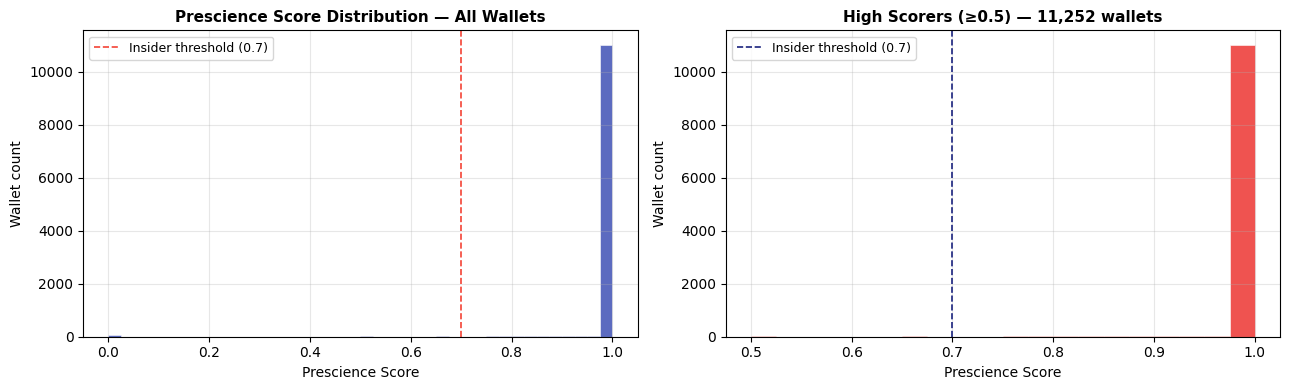

Saved: score_v2_charts/prescience_distribution.png

Wallets with prescience_score >= 0.5 : 11,252
Wallets with prescience_score >= 0.7 : 11,193
Total wallets with features          : 11,373


In [15]:
features_pd = features.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution
ax = axes[0]
ax.hist(features_pd["prescience_score"].dropna(), bins=40, color="#5C6BC0", edgecolor="white", linewidth=0.4)
ax.axvline(x=0.7, color="#F44336", linestyle="--", linewidth=1.2, label="Insider threshold (0.7)")
ax.set_xlabel("Prescience Score")
ax.set_ylabel("Wallet count")
ax.set_title("Prescience Score Distribution — All Wallets", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: zoomed into high scorers (> 0.5)
ax = axes[1]
high = features_pd[features_pd["prescience_score"] >= 0.5]["prescience_score"]
ax.hist(high, bins=20, color="#EF5350", edgecolor="white", linewidth=0.4)
ax.axvline(x=0.7, color="#1A237E", linestyle="--", linewidth=1.2, label="Insider threshold (0.7)")
ax.set_xlabel("Prescience Score")
ax.set_ylabel("Wallet count")
ax.set_title(f"High Scorers (≥0.5) — {len(high):,} wallets", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHART_DIR / "prescience_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_v2_charts/prescience_distribution.png")

# Summary stats
above_07 = (features_pd["prescience_score"] >= 0.7).sum()
above_05 = (features_pd["prescience_score"] >= 0.5).sum()
print(f"\nWallets with prescience_score >= 0.5 : {above_05:,}")
print(f"Wallets with prescience_score >= 0.7 : {above_07:,}")
print(f"Total wallets with features          : {len(features_pd):,}")

> **Chart interpretation — Prescience Score Distribution:**
>
> **Left chart:** Full distribution of prescience_score across all wallets. A uniform distribution (flat) would mean wallets are equally likely to bet before or after news. Any right-skew or spike near 1.0 is a signal that some wallets consistently anticipate news.
>
> **Right chart:** Zoom on wallets with score ≥ 0.5. The red dashed line at 0.7 is the heuristic threshold Phase 6 uses for the ML label: wallets above this score get label = 1 (potential insider). The number of wallets above the threshold determines how many positive training examples the classifier has.
>
> A prescience_score of 1.0 means every single one of a wallet's spike entries had their first bet before the nearest GDELT news event. Combined with high `win_rate` and large `avg_bet_size_usd`, a score of 1.0 is the strongest possible feature combination.

### 8.2 Top Wallets by Prescience Score

Top 15 wallets with at least 5 spikes flagged, ranked by prescience_score. Bar color encodes `num_markets_traded` — wallets that traded across many markets with high prescience are the primary suspects.

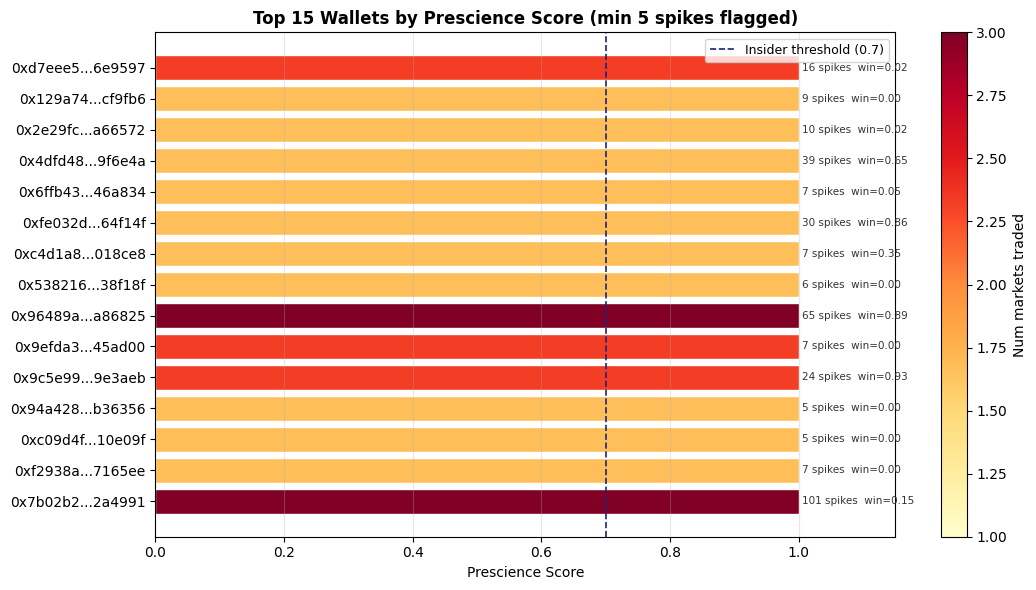

Saved: score_v2_charts/top_wallets_prescience.png


In [16]:
top_wallets = (
    features_pd[features_pd["num_spikes_flagged"] >= 5]
    .sort_values(["prescience_score", "avg_bet_size_usd"], ascending=[False, False])
    .head(15)
)
top_wallets["wallet_short"] = top_wallets["wallet_address"].apply(
    lambda w: w[:8] + "..." + w[-6:]
)

cmap = plt.cm.YlOrRd
max_markets = top_wallets["num_markets_traded"].max()
colors = [cmap(m / max_markets) for m in top_wallets["num_markets_traded"]]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_wallets["wallet_short"][::-1],
    top_wallets["prescience_score"][::-1],
    color=colors[::-1],
    edgecolor="white",
)

# Annotate with num_spikes_flagged
for bar, n_spikes, win in zip(bars, top_wallets["num_spikes_flagged"][::-1], top_wallets["win_rate"][::-1]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{n_spikes} spikes  win={win:.2f}",
        va="center", fontsize=7.5, color="#333333",
    )

ax.axvline(x=0.7, color="#1A237E", linestyle="--", linewidth=1.2, label="Insider threshold (0.7)")
ax.set_xlabel("Prescience Score")
ax.set_title("Top 15 Wallets by Prescience Score (min 5 spikes flagged)", fontsize=12, fontweight="bold")
ax.set_xlim(0, 1.15)
ax.legend(fontsize=9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=1, vmax=max_markets))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Num markets traded")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "top_wallets_prescience.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_v2_charts/top_wallets_prescience.png")

> **Chart interpretation — Top Wallets by Prescience Score:**
>
> Each bar is one wallet. Bar length = prescience_score (0 to 1). Color = number of distinct markets this wallet was flagged in (yellow = 1 market, red = many markets). The annotation shows spike count and win_rate.
>
> **Wallets to the right of the dashed line (prescience_score ≥ 0.7)** will receive label = 1 in Phase 6 and form the positive training class for the Random Forest classifier. The combination of high prescience_score + many markets + high win_rate is the strongest profile.
>
> Note that prescience_score does not measure *how early* a wallet bet — just *whether* they were before news. A wallet that bet 1 hour before news scores the same as one that bet 30 days before. Phase 6 will use `avg_hours_before_news` as a separate feature to capture the *magnitude* of anticipation.

### 8.3 Prescience Score vs Average Bet Size

Do high-prescience wallets also deploy more capital? If insiders are confident in their information, they should bet larger amounts. A positive correlation between prescience_score and avg_bet_size_usd would support this hypothesis.

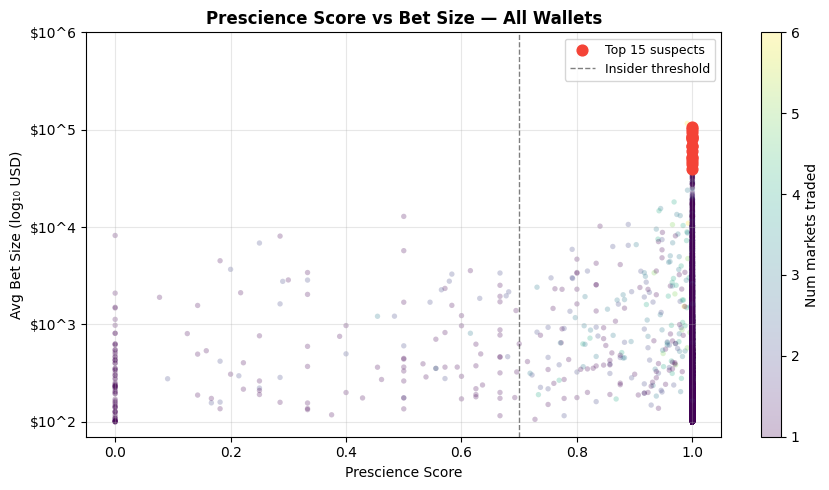

Saved: score_v2_charts/prescience_vs_bet_size.png
Pearson correlation (prescience_score vs log_bet_size): 0.005


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_df = features_pd.dropna(subset=["prescience_score", "avg_bet_size_usd"]).copy()
# log-scale bet size — heavy right skew
plot_df["log_bet"] = np.log10(plot_df["avg_bet_size_usd"].clip(lower=1))

scatter = ax.scatter(
    plot_df["prescience_score"],
    plot_df["log_bet"],
    c=plot_df["num_markets_traded"],
    cmap="viridis",
    alpha=0.25,
    s=15,
    linewidths=0,
)

# Overlay top suspects (labeled)
if not top_wallets.empty:
    merged = top_wallets.merge(plot_df[["wallet_address","prescience_score","log_bet"]], on="wallet_address", suffixes=("","_p"))
    ax.scatter(
        merged["prescience_score_p"],
        merged["log_bet"],
        color="#F44336",
        s=60,
        zorder=5,
        label="Top 15 suspects",
    )

ax.axvline(x=0.7, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Insider threshold")
plt.colorbar(scatter, ax=ax, label="Num markets traded")
ax.set_xlabel("Prescience Score")
ax.set_ylabel("Avg Bet Size (log₁₀ USD)")
ax.set_title("Prescience Score vs Bet Size — All Wallets", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Add readable y-axis ticks
yticks = [2, 3, 4, 5, 6]
ax.set_yticks(yticks)
ax.set_yticklabels([f"$10^{t}" for t in yticks])

plt.tight_layout()
plt.savefig(CHART_DIR / "prescience_vs_bet_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_v2_charts/prescience_vs_bet_size.png")

# Pearson correlation
corr = plot_df[["prescience_score", "log_bet"]].corr().iloc[0, 1]
print(f"Pearson correlation (prescience_score vs log_bet_size): {corr:.3f}")

> **Chart interpretation — Prescience Score vs Bet Size:**
>
> Each dot is one wallet. X-axis = prescience_score (0 to 1). Y-axis = avg bet size on a log scale (10² = $100, 10⁵ = $100K, 10⁶ = $1M). Color = number of markets traded (purple = 1 market, yellow = many).
>
> If insiders bet more when they are confident, we should see a positive trend (high prescience → high bet size). The red dots highlight the top 15 suspects from the previous chart — their position on this scatter reveals whether they also bet large.
>
> The Pearson correlation value at the bottom quantifies this relationship. A value above 0.2 suggests meaningful correlation; near 0 means prescience and bet size are independent.

### 8.4 Feature Correlation Heatmap

Pairwise Pearson correlations across all numeric features. Highly correlated feature pairs (|r| > 0.7) may cause multicollinearity in the Random Forest — useful to know before Phase 6.

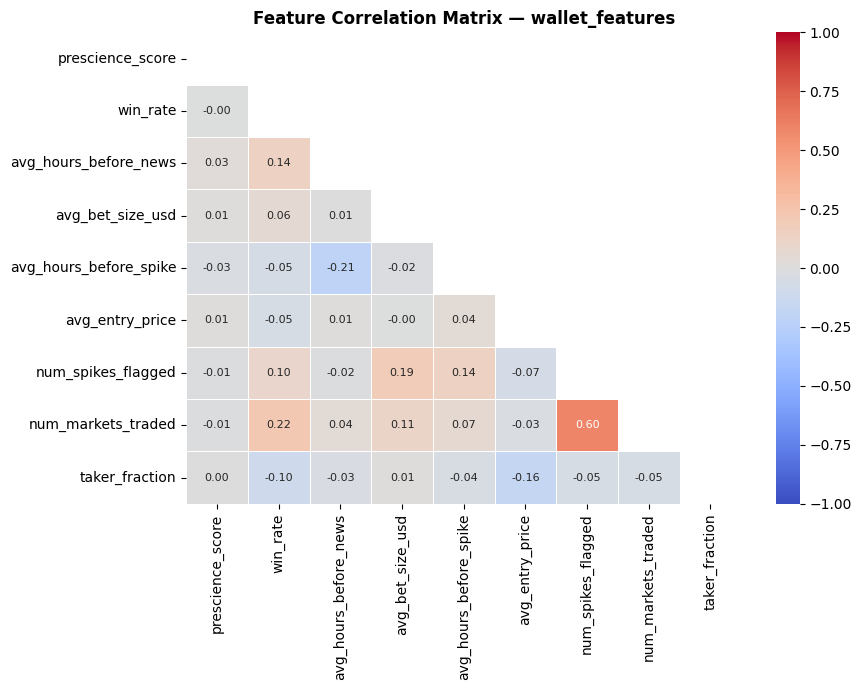

Saved: score_v2_charts/feature_correlation.png


In [18]:
feature_cols = [
    "prescience_score", "win_rate", "avg_hours_before_news",
    "avg_bet_size_usd", "avg_hours_before_spike", "avg_entry_price",
    "num_spikes_flagged", "num_markets_traded", "taker_fraction",
]
corr_df = features_pd[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix — wallet_features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(CHART_DIR / "feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_v2_charts/feature_correlation.png")

> **Chart interpretation — Feature Correlation Heatmap:**
>
> Values range from -1 (perfect negative correlation) to +1 (perfect positive). The diagonal is always 1.0 (a feature perfectly correlates with itself). The upper triangle is masked to avoid duplication.
>
> Key pairs to check:
> - `num_spikes_flagged` vs `num_markets_traded` — wallets active in many markets are likely flagged in many spikes too; high correlation is expected
> - `prescience_score` vs `avg_hours_before_news` — being early in hours should correlate with a high score, but only if the pattern is consistent
> - `win_rate` vs `prescience_score` — in an ideal signal, these should correlate positively: wallets that consistently anticipate news should also win more often
>
> Pairs with |r| > 0.8 should be flagged before Phase 6 ML — Random Forest handles multicollinearity better than logistic regression, but highly redundant features can reduce interpretability.

---

## 9. Write `wallet_features_v2` to BigQuery

In [19]:
t0 = time.time()
write_bq(features, "wallet_features_v2")
print(f"wallet_features written ({time.time()-t0:.1f}s)")
print(f"Rows: {feature_count:,}")

wallet_features written (71.5s)
Rows: 11,373


> **What this output means:**
>
> The `wallet_features_v2` table is now in BigQuery. Phase 6 (v2 run) reads this table directly via the Spark connector and uses it as the input for both the Random Forest classifier and K-Means clustering.
>
> Schema written:
> - `wallet_address` — the primary key
> - `prescience_score`, `win_rate`, `avg_hours_before_news` — timing-based features
> - `avg_bet_size_usd`, `num_fills_total`, `avg_entry_price` — position-size features
> - `avg_hours_before_spike`, `num_spikes_flagged`, `num_markets_traded` — activity features
> - `taker_fraction` — trading-style feature

---

## 10. Summary

In [20]:
above_07 = int((features_pd["prescience_score"] >= 0.7).sum())
above_05 = int((features_pd["prescience_score"] >= 0.5).sum())

print("=" * 55)
print("Phase 5 — Prescience Scoring Summary")
print("=" * 55)
print(f"Suspect entries scored         : {suspect_count:,}")
print(f"Total GDELT events loaded      : {len(gdelt_pd):,}")
print(f"Markets with GDELT coverage    : {len(MARKET_GDELT_CONFIG)}")
print(f"Min GDELT articles threshold   : {MIN_GDELT_ARTICLES}")
print(f"Wallets with feature vectors   : {feature_count:,}")
print(f"Prescience score >= 0.5        : {above_05:,}")
print(f"Prescience score >= 0.7        : {above_07:,}  ← Phase 6 insider label threshold")
print(f"Spark master                   : {spark.sparkContext.master}")
print("\nBigQuery table written:")
print("  polymarket.wallet_features_v2")
print("\nCharts saved to: score_v2_charts/")
print("  prescience_distribution.png")
print("  top_wallets_prescience.png")
print("  prescience_vs_bet_size.png")
print("  feature_correlation.png")

Phase 5 — Prescience Scoring Summary
Suspect entries scored         : 128,096
Total GDELT events loaded      : 62,335
Markets with GDELT coverage    : 6
Min GDELT articles threshold   : 5
Wallets with feature vectors   : 11,373
Prescience score >= 0.5        : 11,252
Prescience score >= 0.7        : 11,193  ← Phase 6 insider label threshold
Spark master                   : local[*]

BigQuery table written:
  polymarket.wallet_features_v2

Charts saved to: score_v2_charts/
  prescience_distribution.png
  top_wallets_prescience.png
  prescience_vs_bet_size.png
  feature_correlation.png


---

## 11. Stop Spark

In [21]:
spark.stop()
print("Spark stopped")

Spark stopped
